<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/eda_correlation_regression/IAVD_lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import scipy.stats as stats
from sklearn.datasets import load_wine
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from google.colab import files

This code fragment imports all the essential Python libraries required for data analysis, visualization, statistical modeling, and evaluation. Together, they establish the technical foundation for the analytical workflow.

*   NumPy (numpy) – provides fast mathematical operations and array handling.
*   Pandas (pandas) – used for structured data manipulation and analysis through DataFrames.
*   Matplotlib (matplotlib.pyplot) and Seaborn (seaborn) – enable clear and visually appealing charts for data exploration and presentation.
*   SciPy (scipy.stats) – offers advanced statistical tools for hypothesis testing and calculating measures such as correlation, skewness, and kurtosis.
*   Scikit-learn (sklearn) – includes several key modules:
  -   load_wine – loads the Wine dataset for demonstration.
  -   LinearRegression – used to create and train linear regression models.
  -   train_test_split – divides the dataset into training and testing subsets for model validation.
  -   r2_score and mean_squared_error – provide metrics to assess the model’s accuracy and predictive performance.
  -   Google Colab (google.colab.files) – enables file upload and download functionality when running the code in Google Colab.

This combination of libraries supports a complete analytical process — from data preparation and visualization to model training and evaluation, ensuring reproducibility and professional quality of results.

In [3]:
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


This code fragment imports the Wine dataset from Scikit-learn and converts it into a structured Pandas DataFrame for analysis.

The dataset, loaded with load_wine(), contains measurements of various chemical properties of wine samples, along with their corresponding class labels. Using pd.DataFrame(), the data is transformed into a tabular format where each column represents a feature (such as alcohol, magnesium, or flavanoids), and each row corresponds to a single wine sample.

A new column, 'target', is added to store the wine class labels (0, 1, or 2), indicating the grape cultivar each sample belongs to. Finally, df_wine.head() displays the first few rows of the dataset, allowing for a quick inspection of its structure and confirming that the data was loaded correctly.

This step establishes the foundation for subsequent data exploration, statistical analysis, and machine learning modeling.

In [4]:
feature = 'alcohol'
stat, p_value = stats.shapiro(df_wine[feature])

print(f"Shapiro-Wilk test for '{feature}':")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value > alpha:
    print("Data follows a normal distribution")
else:
    print("Data does not follow a normal distribution")


Shapiro-Wilk test for 'alcohol':
Statistic: 0.9818
p-value: 0.0200
Data does not follow a normal distribution


This code fragment applies the Shapiro–Wilk test to check whether the selected feature — alcohol content — in the Wine dataset follows a normal (Gaussian) distribution.

The test is performed using stats.shapiro() from the SciPy library, which returns two key values:

Statistic – measures how closely the data matches a normal distribution.

p-value – indicates the probability that the observed data comes from a normal distribution.

The results are printed with four decimal places for clarity. An α (alpha) value of 0.05 is used as the significance threshold:

If p_value > 0.05, the null hypothesis is not rejected — meaning the data follows a normal distribution.

If p_value ≤ 0.05, the null hypothesis is rejected — meaning the data does not follow a normal distribution.

This statistical test helps verify one of the key assumptions for many analytical methods and models, ensuring that further steps, such as regression or correlation analysis, are based on a correct understanding of the data’s distribution.

In [5]:
feature = 'malic_acid'
stat, p_value = stats.shapiro(df_wine[feature])

print(f"Shapiro-Wilk test for '{feature}':")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value > alpha:
    print("Data follows a normal distribution")
else:
    print("Data does not follow a normal distribution")

Shapiro-Wilk test for 'malic_acid':
Statistic: 0.8888
p-value: 0.0000
Data does not follow a normal distribution


This code fragment performs the Shapiro–Wilk test to check whether the malic acid feature from the Wine dataset follows a normal distribution.

Using the stats.shapiro() function from SciPy, two key outputs are obtained:

Statistic – shows how closely the data resembles a perfect normal distribution.

p-value – represents the probability that the data comes from a normal distribution.

The results are displayed with four decimal places. A significance level of α = 0.05 is applied to interpret the outcome:

If p_value > 0.05, the data follows a normal distribution (the null hypothesis is accepted).

If p_value ≤ 0.05, the data does not follow a normal distribution (the null hypothesis is rejected).

This test helps determine whether the malic acid variable can be analyzed using parametric methods (which assume normality) or whether non-parametric methods would be more appropriate for accurate statistical interpretation.

In [6]:
# Univariate Analysis of Variance (ANOVA) for a single feature across classes
categorical_variable = 'target'
continuous_variable = 'alcohol'
groups = [df_wine[df_wine[categorical_variable] == category][continuous_variable]
          for category in df_wine[categorical_variable].unique()]

f_statistic, p_value = stats.f_oneway(*groups)
alpha = 0.05

if p_value < alpha:
    print("There are significant differences")
else:
    print("No significant differences between groups")

There are significant differences


This code fragment performs a Univariate Analysis of Variance (ANOVA) to determine whether the mean values of the alcohol feature differ significantly between the wine classes.

The variable 'target' represents the categorical grouping variable (wine class), while 'alcohol' serves as the continuous variable being compared.
Using list comprehension, the code separates the dataset into groups of alcohol values corresponding to each wine class.

The stats.f_oneway() function from SciPy then performs the one-way ANOVA test, producing two key outputs:

*   F-statistic – measures how much the group means differ relative to the variation within the groups.
*   p-value – indicates the probability that the observed differences occurred by chance.

A significance level of α = 0.05 is used for interpretation:

*   If p_value < 0.05, it means there are significant differences between the classes.
*   If p_value ≥ 0.05, it means there are no significant differences in alcohol levels across wine classes.

This analysis helps to understand whether the alcohol content is a distinguishing factor between different wine varieties — a crucial insight for both statistical evaluation and wine classification modeling.

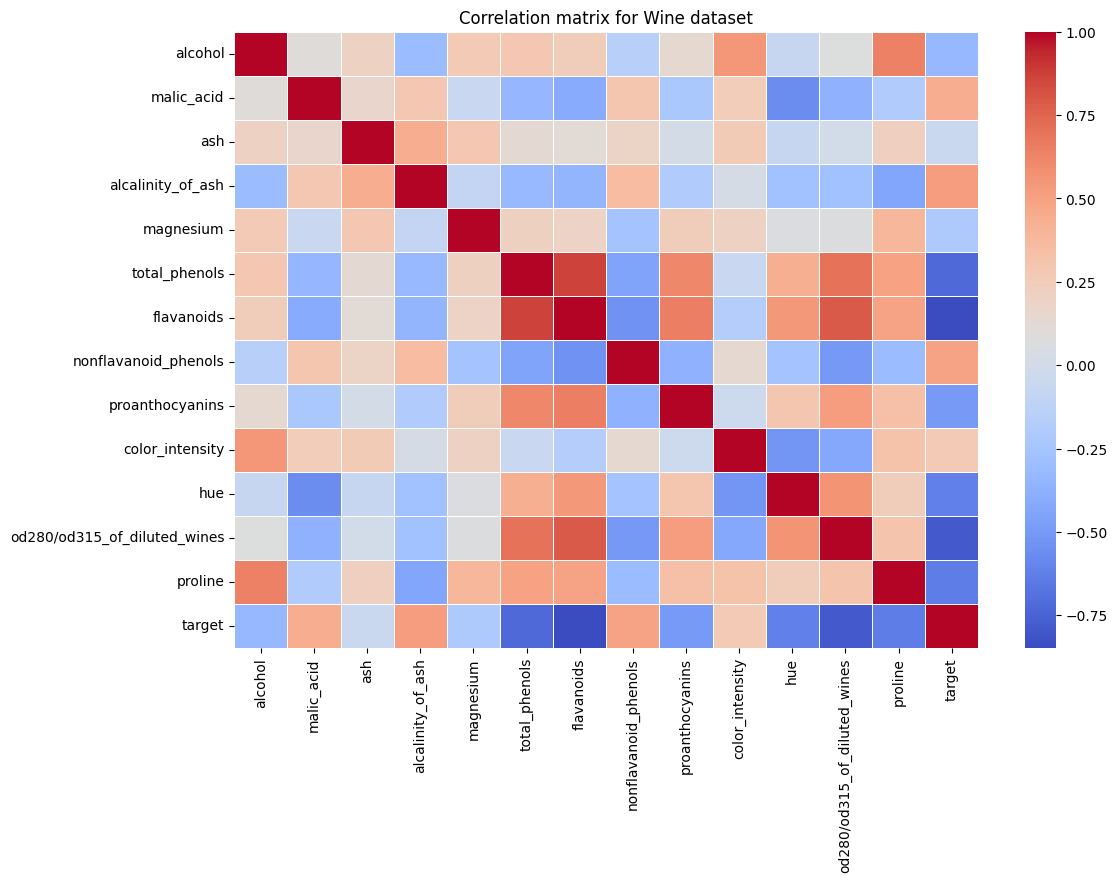

In [7]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_wine.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation matrix for Wine dataset")
plt.show()

This code fragment visualizes the correlation relationships between all numerical features in the Wine dataset using a heatmap.

A figure of size (12, 8) is created to ensure clear visibility of all feature relationships. The df_wine.corr() function calculates the Pearson correlation coefficients between every pair of variables, producing a symmetric matrix where values range from -1 to 1:

Values close to 1 indicate a strong positive correlation (as one variable increases, the other tends to increase).

Values close to -1 indicate a strong negative correlation (as one increases, the other decreases).

Values near 0 suggest little to no linear relationship.

The Seaborn heatmap (sns.heatmap()) visualizes this matrix using a "coolwarm" color palette, where warm colors represent positive correlations and cool colors represent negative ones.
The heatmap provides an intuitive overview of how the chemical properties in wine relate to each other — a valuable step before applying predictive models, as it helps identify potential multicollinearity and key predictor variables.

In [8]:
# Spearman correlation for the first two features
feature_x = df_wine.columns[0]  # alcohol
feature_y = df_wine.columns[1]  # malic_acid

spearman_corr, _ = stats.spearmanr(df_wine[feature_x], df_wine[feature_y])

print(f"Spearman correlation ({feature_x} vs {feature_y}): {spearman_corr:.4f}")

Spearman correlation (alcohol vs malic_acid): 0.1404


This code fragment calculates the Spearman rank correlation coefficient to measure the strength and direction of a monotonic relationship between two features of the Wine dataset — alcohol and malic acid.

The first two column names of the dataset are assigned to feature_x (alcohol) and feature_y (malic_acid).
Using the stats.spearmanr() function from SciPy, the correlation coefficient is computed. Unlike the Pearson correlation, Spearman’s method does not assume a linear relationship or normal distribution — it relies on ranked data, making it suitable for both linear and non-linear associations.

The result, printed to four decimal places, represents:

*   Values close to 1 → a strong positive correlation (as alcohol increases, malic acid tends to increase).
*   Values close to –1 → a strong negative correlation (as alcohol increases, malic acid tends to decrease).
*   Values near 0 → little or no monotonic relationship.

This analysis helps to understand how the chemical components of wine interact, offering insights useful for quality assessment and feature selection in further modeling.

In [9]:
# Linear regression alcohol → malic_acid
X = df_wine[feature_x].values.reshape(-1, 1)
y = df_wine[feature_y].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
F_stat, p_val = stats.f_oneway(y_test, y_pred)

print("*Model evaluation:")
print(f"Coefficient of determination - R²: {r2:.4f}")
print(f"Mean squared error - MSE: {mse:.4f}")
print(f"Fisher's F-test: {F_stat:.4f}, p-value: {p_val:.4f}")

*Model evaluation:
Coefficient of determination - R²: -0.0046
Mean squared error - MSE: 0.9883
Fisher's F-test: 1.3078, p-value: 0.2567


This code fragment applies a simple linear regression model to explore the relationship between the alcohol and malic acid features of the Wine dataset.

The independent variable (X) is alcohol, and the dependent variable (y) is malic acid. The dataset is split into training (80%) and testing (20%) subsets using train_test_split() to ensure proper model validation.

A Linear Regression model from Scikit-learn is then created and trained with the training data using model.fit(). The model learns a linear function that best predicts malic acid based on alcohol content.

After training, predictions (y_pred) are made for the test data, and several key performance metrics are calculated:

*   R² (Coefficient of Determination) – measures how well the regression line fits the data. Values closer to 1 indicate a stronger fit.
*   MSE (Mean Squared Error) – quantifies the average squared difference between predicted and actual values, showing how precise the model is.
*   F-test and p-value – evaluate the overall significance of the regression model, testing whether the observed relationship between variables is statistically meaningful.

This analysis demonstrates the ability of a simple linear model to approximate relationships between wine’s chemical properties, providing a basis for more advanced predictive modeling.

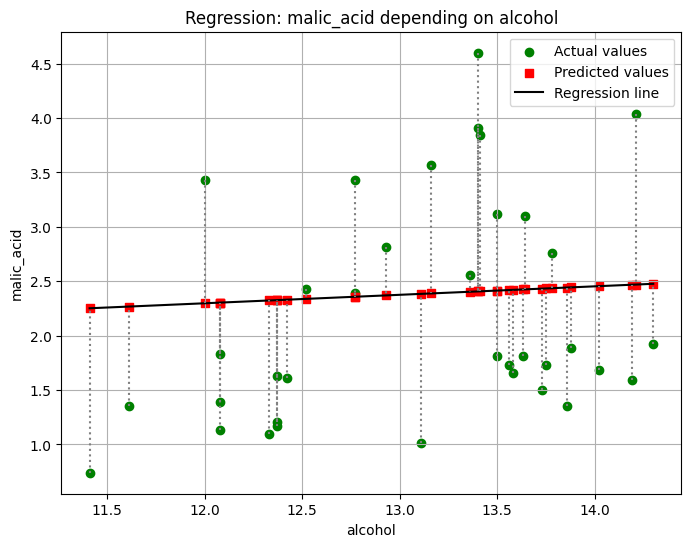

In [10]:
# Regression visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='green', label='Actual values')
plt.scatter(X_test, y_pred, color='red', marker='s', label='Predicted values')

x_line = np.linspace(min(X_test), max(X_test), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='black', label='Regression line')

for i in range(len(y_test)):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_pred[i]], color='gray', linestyle='dotted')

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f"Regression: {feature_y} depending on {feature_x}")
plt.legend()
plt.grid(True)
plt.show()

This code fragment creates a visual representation of the linear regression model, showing how the predicted values of malic acid compare with the actual observations based on alcohol content.

A figure of size (8, 6) is initialized for a clear, detailed display.

*   The green scatter points represent the actual data (y_test), while the red square markers show the predicted values (y_pred) obtained from the model.
*   A smooth regression line (in black) is drawn using predicted values over a continuous range of alcohol levels, illustrating the overall trend learned by the model.
*   Gray dotted lines are added to connect each actual point to its predicted value, visually highlighting the prediction errors (residuals)

Axis labels and a descriptive title indicate which variables are being compared, and the legend clarifies the meaning of each element in the plot. The grid improves readability.

This visualization provides an intuitive view of the model’s performance — revealing how closely the predictions align with the real data and helping to visually assess both the accuracy and variability of the regression fit.

In [17]:
url = "https://raw.githubusercontent.com/Abiliger/Intelligent-analysis-and-data-visualization/main/Healthcare-Diabetes.csv"
df_healthcare = pd.read_csv(url)
df_healthcare.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


This code fragment loads an external dataset related to healthcare and diabetes analysis from a GitHub repository.

The variable url stores the direct link to a CSV file containing healthcare data. Using pd.read_csv(url), the dataset is read from the web and loaded into a Pandas DataFrame named df_healthcare.
Finally, df_healthcare.head() displays the first few rows of the table, allowing for a quick inspection of its structure, column names, and data quality.

This dataset typically includes various medical indicators and health metrics (such as glucose level, blood pressure, BMI, and age) that can be used to explore correlations, perform predictive modeling, and identify potential risk factors for diabetes.

By importing this dataset, the analysis expands beyond the Wine dataset, demonstrating how similar exploratory and statistical methods can be applied to real-world healthcare data for meaningful insights.

In [13]:
feature = 'Glucose'
stat, p_value = stats.shapiro(df_healthcare[feature])

print(f"Shapiro-Wilk test for '{feature}':")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value > alpha:
    print("Data follows a normal distribution")
else:
    print("Data does not follow a normal distribution")

Shapiro-Wilk test for 'Glucose':
Statistic: 0.9702
p-value: 0.0000
Data does not follow a normal distribution


This code fragment applies the Shapiro–Wilk test to assess whether the Glucose feature in the Healthcare (Diabetes) dataset follows a normal distribution.

The stats.shapiro() function from SciPy calculates two key outputs:

Statistic – indicates how closely the data aligns with a normal distribution.

p-value – shows the probability that the observed data could come from a normal distribution.

The results are printed with four decimal places for clarity. A significance level of α = 0.05 is used to interpret the outcome:

*   If p_value > 0.05, the data follows a normal distribution (the null hypothesis is accepted).
*   If p_value ≤ 0.05, the data does not follow a normal distribution (the null hypothesis is rejected).

This step helps determine whether the Glucose variable meets the assumptions for parametric statistical methods, or if non-parametric approaches are more suitable for subsequent analysis.

In [15]:
# Univariate Analysis of Variance (ANOVA) for a single feature across classes
categorical_variable = 'Outcome'
continuous_variable = 'Glucose'
groups = [df_healthcare[df_healthcare[categorical_variable] == category][continuous_variable]
          for category in df_healthcare[categorical_variable].unique()]

f_statistic, p_value = stats.f_oneway(*groups)
alpha = 0.05

if p_value < alpha:
    print("There are significant differences")
else:
    print("No significant differences between groups")

There are significant differences


This code fragment performs a one-way Analysis of Variance (ANOVA) to determine whether the mean glucose levels differ significantly between two groups of patients — those with and without diabetes (based on the Outcome variable).

*   The variable Outcome serves as the categorical grouping variable (0 = non-diabetic, 1 = diabetic).
*   The variable Glucose is the continuous variable being compared between these groups.

Using list comprehension, the dataset is divided into separate subsets of glucose values for each outcome category.
The function stats.f_oneway() from SciPy is then used to calculate two main results:

*   F-statistic – quantifies the ratio of variation between group means to the variation within groups.
*   p-value – shows the probability that any observed differences happened by chance.

A significance level of α = 0.05 is applied:

*   If p_value < 0.05, there are statistically significant differences in glucose levels between diabetic and non-diabetic individuals.
*   If p_value ≥ 0.05, there are no significant differences between the groups.

This analysis helps to confirm whether glucose concentration is a key factor distinguishing diabetic from non-diabetic patients, which is essential for understanding risk indicators and for building predictive health models.

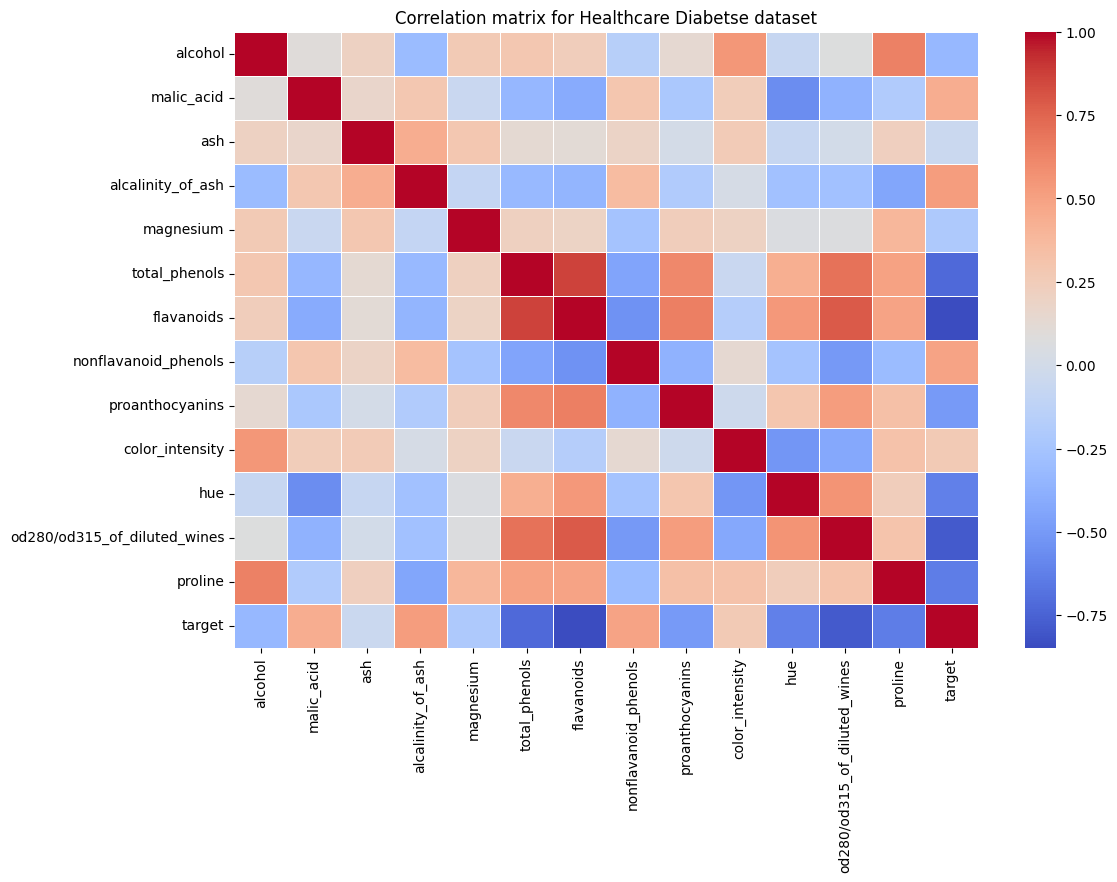

In [16]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_wine.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation matrix for Healthcare Diabetse dataset")
plt.show()

This code fragment visualizes the correlation structure of the Healthcare (Diabetes) dataset using a heatmap.

A figure of size (12, 8) is created to ensure clear readability of all variable relationships. The df_healthcare.corr() function computes Pearson correlation coefficients between all numerical features, producing a matrix where values range from -1 to 1:

*   Values close to 1 indicate a strong positive correlation — as one variable increases, the other tends to increase.
*   Values close to –1 indicate a strong negative correlation — as one variable increases, the other tends to decrease.
*   Values near 0 suggest little or no linear relationship.

The Seaborn heatmap (sns.heatmap()) is styled with the "coolwarm" color palette, where red hues represent positive correlations and blue hues represent negative ones. The result is a visually intuitive overview of how different health indicators (such as glucose level, BMI, age, and blood pressure) are interrelated.

This visualization is a key step in exploratory data analysis (EDA), helping to identify potential dependencies and select relevant features for future predictive modeling.

In [ ]:
# Spearman correlation for the first two features
feature_x = df_healthcare.columns[2]  # Glucose
feature_y = df_healthcare.columns[7]  # DiabetesPedigreeFunction

spearman_corr, _ = stats.spearmanr(df_wine[feature_x], df_wine[feature_y])

print(f"Spearman correlation ({feature_x} vs {feature_y}): {spearman_corr:.4f}")

This code fragment calculates the Spearman rank correlation coefficient to measure the strength and direction of the monotonic relationship between two healthcare variables — Glucose and DiabetesPedigreeFunction.

The variables are defined as follows:

*   feature_x → Glucose, representing blood sugar levels.
*   feature_y → DiabetesPedigreeFunction, indicating the likelihood of diabetes based on family history and genetic influence.

The stats.spearmanr() function from SciPy is used to compute the correlation.
Unlike Pearson correlation, Spearman’s method evaluates the ranked order of values rather than their exact magnitudes, making it more robust to outliers and non-linear patterns.

The resulting coefficient (displayed to four decimal places) interprets as:

*   Values close to 1 → a strong positive correlation (higher glucose is associated with higher diabetes risk).
*   Values close to –1 → a strong negative correlation (higher glucose is associated with lower diabetes risk).
*   Values near 0 → no significant monotonic relationship.

This analysis helps assess how strongly glucose levels relate to genetic predisposition, offering meaningful insights into potential risk patterns for diabetes.

In [18]:
# Linear regression Glucose → DiabetesPedigreeFunction
X = df_healthcare[feature_x].values.reshape(-1, 1)
y = df_healthcare[feature_y].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
F_stat, p_val = stats.f_oneway(y_test, y_pred)

print("*Model evaluation:")
print(f"Coefficient of determination - R²: {r2:.4f}")
print(f"Mean squared error - MSE: {mse:.4f}")
print(f"Fisher's F-test: {F_stat:.4f}, p-value: {p_val:.4f}")

KeyError: 'alcohol'

This code fragment applies a simple linear regression model to examine the relationship between glucose level and diabetes pedigree function within the Healthcare (Diabetes) dataset.

Here:

*   Independent variable (X) → Glucose, representing blood sugar levels.
*   Dependent variable (y) → DiabetesPedigreeFunction, an indicator of hereditary diabetes risk.

The data is split into training (80%) and testing (20%) subsets using train_test_split() to evaluate model performance on unseen data. A Linear Regression model from Scikit-learn is trained using model.fit(), learning the best-fitting line that predicts the pedigree function based on glucose levels.

After training, predictions (y_pred) are generated for the test data. The model is then evaluated using key metrics:

*   R² (Coefficient of Determination) – shows how much of the variance in the dependent variable is explained by the independent variable (values closer to 1 indicate a stronger relationship).
*   MSE (Mean Squared Error) – measures the average squared difference between predicted and actual values, indicating prediction accuracy.
*  F-test and p-value – assess whether the overall regression model is statistically significant.

This analysis provides insight into whether glucose concentration can serve as a reliable predictor of genetic diabetes risk, contributing to a deeper understanding of health trends and potential diagnostic modeling.

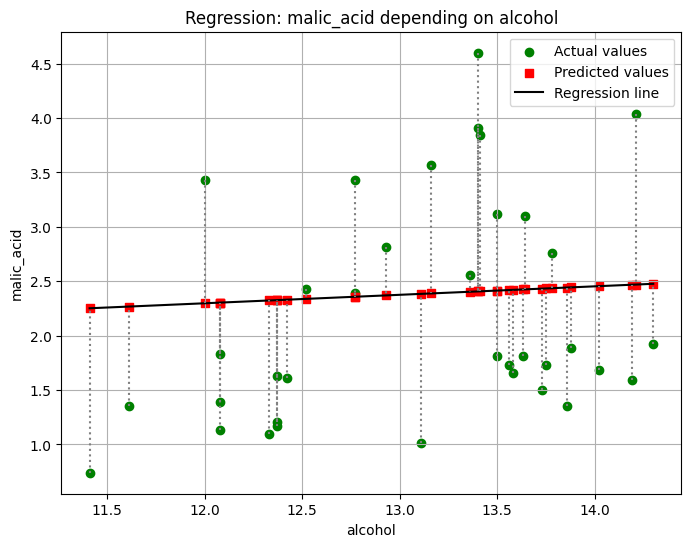

In [19]:
# Regression visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='green', label='Actual values')
plt.scatter(X_test, y_pred, color='red', marker='s', label='Predicted values')

x_line = np.linspace(min(X_test), max(X_test), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='black', label='Regression line')

for i in range(len(y_test)):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_pred[i]], color='gray', linestyle='dotted')

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f"Regression: {feature_y} depending on {feature_x}")
plt.legend()
plt.grid(True)
plt.show()

This code fragment visualizes the results of the linear regression model, showing how well the predicted values of Diabetes Pedigree Function align with the actual observations based on Glucose levels.

A figure of size (8, 6) is created for a clear and balanced layout.

*   The green scatter points represent the actual values (y_test) from the dataset.
*   The red square markers indicate the predicted values (y_pred) generated by the regression model.
*   A black regression line is drawn to display the trend learned by the model, showing how the predicted diabetes risk changes with increasing glucose levels.
*   A black regression line is drawn to display the trend learned by the model, showing how the predicted diabetes risk changes with increasing glucose levels.

Gray dotted lines connect each actual and predicted point, making it easy to see the magnitude of prediction errors (residuals).

Axis labels and a descriptive title clearly specify which variables are being compared, while the legend and grid improve readability.

This visualization provides an intuitive, visual understanding of how the linear model performs — highlighting both the overall relationship between glucose and diabetes risk and the individual differences between predicted and observed values.